Load Data

In [1]:
import torch
from data_split import load_data, concat_datasets
import numpy as np
import random

seed = 2026
random.seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
rng = np.random.default_rng(seed)
torch.cuda.manual_seed_all(seed)

dataset_name = "bm_multiome_rna"  
setting = "setting1"  

omics = 1

omics1_train_loader, omics1_test_id_loader, omics1_test_ood_loader, global_categories_id, global_categories_ood, mapping_ood, gene_name =load_data(dataset_name, setting, omics=1)
if omics1_test_id_loader is None:
    omics1_mixed_loader = omics1_test_ood_loader
else:
    omics1_mixed_loader = concat_datasets(omics1_test_id_loader, omics1_test_ood_loader)
    all_data_loader = concat_datasets(omics1_train_loader, omics1_mixed_loader)

print(f'ID: {global_categories_id}')
print(f'OOD: {global_categories_ood}')
print(f'Mapping OOD: {mapping_ood}')

print(len(global_categories_id))

[INFO] Split Train and Test Data by Batch: Train: ['0']
[INFO] Split Train and Test Data by Batch: Test: ['1']


Index(['BcellPre', 'DC', 'ETP', 'Ery', 'EryPre', 'HSPC', 'MEP', 'MyeloidPre'], dtype='object')
ID: Index(['BcellPre', 'DC', 'ETP', 'Ery', 'EryPre', 'HSPC', 'MEP', 'MyeloidPre'], dtype='object')
OOD: Index(['Mono', 'Mono2', 'MonoPre'], dtype='object')
Mapping OOD: {8: 'Mono', 9: 'MonoPre', 10: 'Mono2'}
8


Initialize the model

In [2]:
from scDiscovery_architecture import *
import torch.optim as optim

class_number = len(global_categories_id)

device = torch.device("cuda:3")

omics1_imput_size = omics1_train_loader.dataset[0][0].shape[0]

E_rna = Encoder(input_size=omics1_imput_size, z_dim=128).to(device)
Classifier = JointClassificationHead(z_dim=128, n_classes=class_number).to(device)

optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.001, weight_decay=1e-4)

scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)

Contrastive-Reconstruction Representation Learning (CRRL)

In [3]:
from scDiscovery_architecture import Decoder
from algorithm_utils import train_single_omics

D_rna = Decoder(input_size=omics1_imput_size, z_dim=128).to(device)

optimizer_D_rna = optim.Adam(D_rna.parameters(), lr=0.001, weight_decay=1e-4)

scheduler_D_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D_rna, T_max=100)

E_rna, D_rna, Classifier = train_single_omics(E_rna, D_rna, Classifier, optimizer_E_rna, optimizer_D_rna, optimizer_fc, scheduler_E_rna, scheduler_D_rna, scheduler_fc, omics1_train_loader, omics1_test_id_loader, num_epochs=5, device=device)


Adaptive Decision Boundary Calibration (ADBC)

=================== Before Calibration ===================


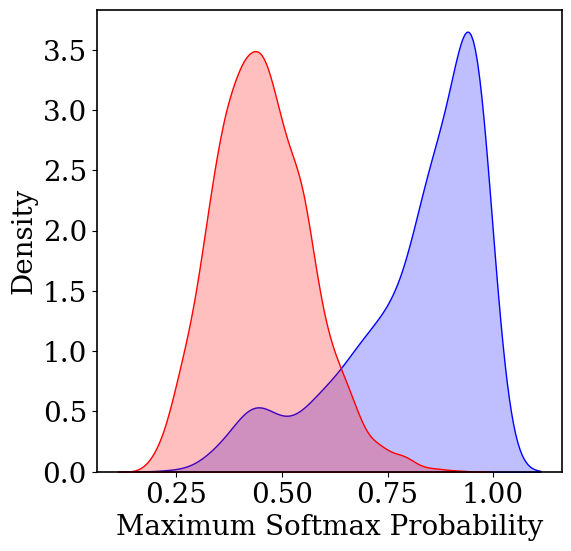

=================== After Calibration ===================


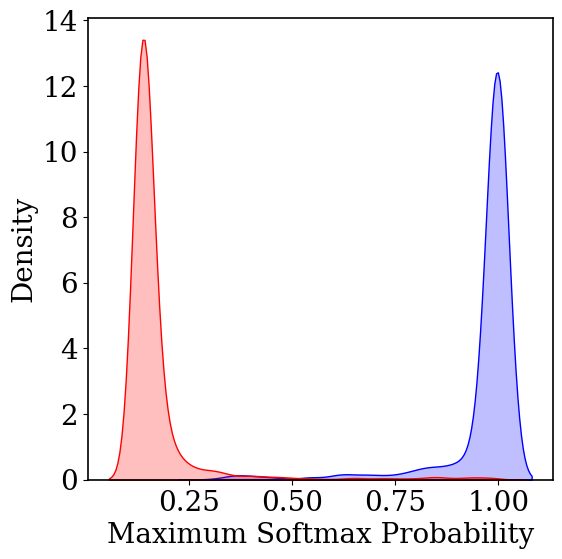

Empty dataset detected. Increase threshold to 0.2000 and retry... [1/10]
=================== ROC Curve ===================


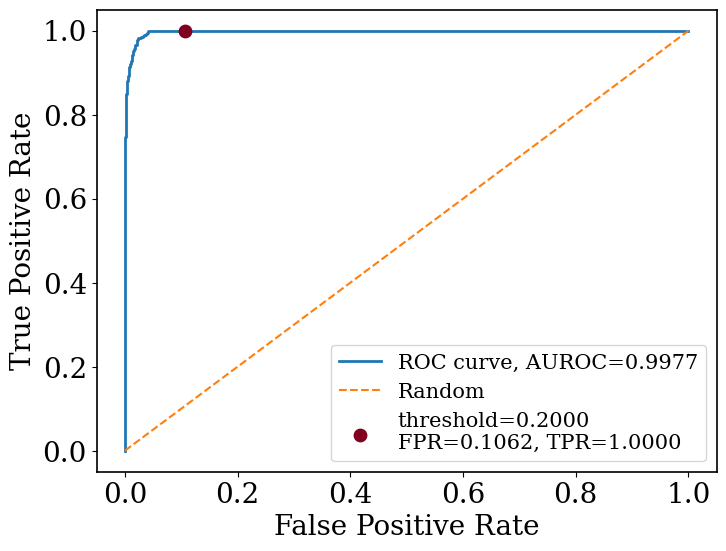

In [4]:
from calibration import adaptive_decision_boundary_calibration

optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.001, weight_decay=1e-4)

scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)

threshold, filtered_omics1_ood_loader, filtered_omics1_id_loader = adaptive_decision_boundary_calibration(E_rna, Classifier, optimizer_E_rna, optimizer_fc, scheduler_E_rna, scheduler_fc, omics1_train_loader,omics1_test_id_loader, omics1_test_ood_loader, omics1_mixed_loader, class_number, device, dataset_name, setting, num_iters=1, num_epochs=5, recall_level=0.95)

Dynamic Novel Cell Type Expansion (DNCTE)

In [5]:
from dynamic_expansion import dynamic_novel_cell_type_expansion

adata, E_rna, D_rna, Classifier_expanded = dynamic_novel_cell_type_expansion(E_rna, D_rna, Classifier, optimizer_E_rna, optimizer_D_rna, scheduler_E_rna, scheduler_D_rna, filtered_omics1_ood_loader, omics1_train_loader, omics1_test_id_loader, omics1_mixed_loader, gene_name, class_number, dataset_name, num_epochs=5, device=device)

Evaluation

In [6]:
from metrics import evaluate_discovery_potential
metrics = evaluate_discovery_potential(
    adata=adata,
    y_true='y_true_with_unknown',
    y_pred='y_pred_with_unknown',
    embed_key='X_scDiscovery',
    unknown_label='Unknown'
)

for k, v in metrics.items():
    print(f"{k}: {v}")

Multi-F1: 0.9845895105817601
Multi-Accuracy: 0.9845981517782134
F1: 0.9962560838637214
Precision: 0.9977502812148481
Recall: 0.994766355140187


In [7]:
from metrics import evaluate_model_on_novel_cell_type

metrics_ood, _, recon_data_ood, y_true_ood, y_pred_ood, Emb_ood = evaluate_model_on_novel_cell_type(E_rna, D_rna, Classifier_expanded, omics1_test_ood_loader, device)  # train_rna_loader  omics1_test_ood_loader

print("Metrics:")
for k, v in metrics_ood.items():
        print(f"{k}: {v}")

Metrics:
ARI: 0.9146514869200775
AMI: 0.7447004446787521
NMI: 0.7451795235724289
HOM: 0.701466615745651


Visualization

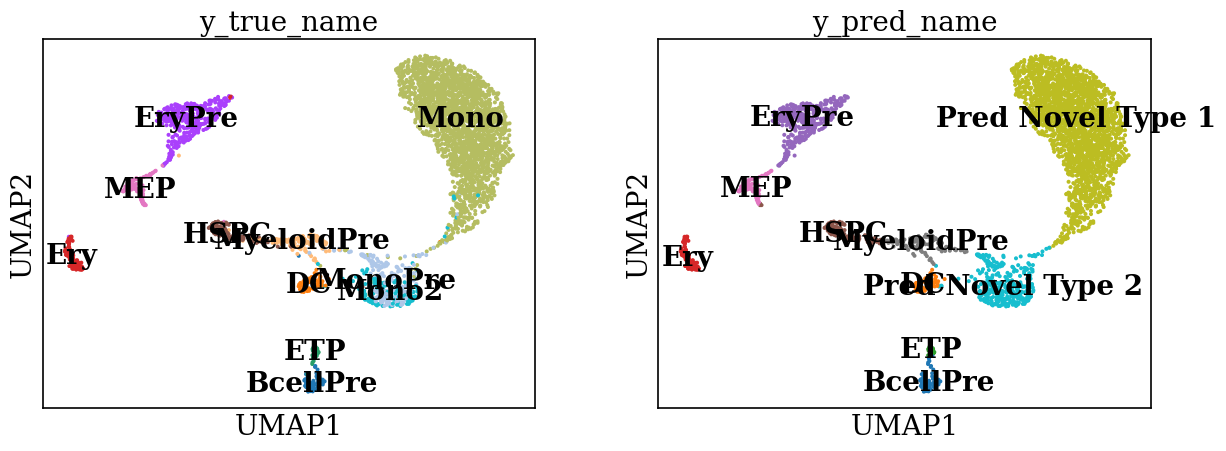

In [8]:
import scanpy as sc
from dynamic_expansion import cell_type_mapping

adata = cell_type_mapping(adata, global_categories_id, mapping_ood)

sc.pp.neighbors(adata, use_rep='X_scDiscovery', metric="cosine")
sc.tl.umap(adata)

sc.pl.umap(adata, color=['y_true_name', 'y_pred_name'], legend_loc='on data', save=f"_scDiscovery_umap_label_{dataset_name}_{setting}.png")